In [6]:
# pip install textblob

# import nltk
# nltk.download('punkt')
# nltk.download('averaged_perceptron_tagger')

# import sys
# !{sys.executable} -m pip install textblob

# !{sys.executable} -m pip install transformers torch

In [7]:
from textblob import TextBlob

text = "The Tanzanian economy is growing strongly this year"
blob = TextBlob(text)

print(blob.sentiment)
# Output: Sentiment(polarity=0.5, subjectivity=0.4)

Sentiment(polarity=0.43333333333333335, subjectivity=0.7333333333333334)


In [8]:
from textblob import TextBlob

headlines = [
    "Tanzania shilling weakens against dollar amid global uncertainty", # negative
    "BOT holds policy rate at 5.5% amid stable inflation", # neutral
    "M-Pesa hits record TZS 8 trillion in February transactions", # positive
    "Fuel prices rise sharply following import cost increases", # negative
    "New fintech regulations boost investor confidence in Tanzania" # positive
]

for headline in headlines:
    score = TextBlob(headline).sentiment.polarity
    
    if score > 0.1:
        label = "Positive"
    elif score < -0.1:
        label = "Negative"
    else:
        label = "Neutral"
    
    print(f"{score:.2f}  {label}  →  {headline}")

0.00  Neutral  →  Tanzania shilling weakens against dollar amid global uncertainty
0.00  Neutral  →  BOT holds policy rate at 5.5% amid stable inflation
0.00  Neutral  →  M-Pesa hits record TZS 8 trillion in February transactions
0.00  Neutral  →  Fuel prices rise sharply following import cost increases
0.14  Positive  →  New fintech regulations boost investor confidence in Tanzania


In [9]:
# The accuracy is  actually so terrible lets test other models

from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk

# nltk.download('vader_lexicon') needs to run once to get training file

sia = SentimentIntensityAnalyzer()

headlines = [
    "Tanzania shilling weakens against dollar amid global uncertainty", # negative
    "BOT holds policy rate at 5.5% amid stable inflation", # neutral
    "M-Pesa hits record TZS 8 trillion in February transactions", # positive
    "Fuel prices rise sharply following import cost increases", # negative
    "New fintech regulations boost investor confidence in Tanzania" # positive
]

for headline in headlines:
    scores = sia.polarity_scores(headline)
    compound = scores['compound']
    
    if compound > 0.05:
        label = "Positive"
    elif compound < -0.05:
        label = "Negative"
    else:
        label = "Neutral"
    
    print(f"{compound:.2f}  {label}  →  {headline}")

-0.57  Negative  →  Tanzania shilling weakens against dollar amid global uncertainty
0.30  Positive  →  BOT holds policy rate at 5.5% amid stable inflation
0.00  Neutral  →  M-Pesa hits record TZS 8 trillion in February transactions
0.00  Neutral  →  Fuel prices rise sharply following import cost increases
0.72  Positive  →  New fintech regulations boost investor confidence in Tanzania


In [10]:
# from transformers import pipeline
# # installing finbert financial model
# finbert = pipeline("text-classification", model="ProsusAI/finbert")

In [11]:
headlines = [
    "Tanzania shilling weakens against dollar amid global uncertainty", # negative
    "BOT holds policy rate at 5.5% amid stable inflation", # neutral
    "M-Pesa hits record TZS 8 trillion in February transactions", # positive
    "Fuel prices rise sharply following import cost increases", # negative
    "New fintech regulations boost investor confidence in Tanzania" # positive
]

results = finbert(headlines)

for headline, result in zip(headlines, results):
    print(f"{result['score']:.2f}  {result['label']}  →  {headline}")

0.94  negative  →  Tanzania shilling weakens against dollar amid global uncertainty
0.76  neutral  →  BOT holds policy rate at 5.5% amid stable inflation
0.79  positive  →  M-Pesa hits record TZS 8 trillion in February transactions
0.56  positive  →  Fuel prices rise sharply following import cost increases
0.94  positive  →  New fintech regulations boost investor confidence in Tanzania


In [12]:
import pandas as pd

df = pd.read_csv("project_testing.csv", on_bad_lines="skip")
df.head()

,date,headline,source,category,sentiment,tzs_usd_rate,inflation_rate,bot_policy_rate
0,2022-01-05,Bank of Tanzania holds benchmark rate steady a...,Daily News,Policy,Neutral,2300,3.5,5.0
1,2022-01-12,Tanzania shilling opens year on firm footing a...,The Citizen,Forex,Positive,2300,3.5,5.0
2,2022-01-18,M-Pesa Tanzania records 30% surge in mobile tr...,IPP Media,Fintech,Positive,2300,3.5,5.0
3,2022-01-25,CRDB Bank posts strong full-year profit driven...,The Citizen,Banking,Positive,2300,3.5,5.0
4,2022-02-03,Tanzania inflation holds at 3.5% as food price...,Daily News,Policy,Neutral,2308,3.5,5.0


In [13]:
# creating functions for sentiments for text block and vader

from transformers import pipeline
finbert = pipeline("text-classification", model="ProsusAI/finbert")

from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

def vadernltk_sentiment(headline):
    scores = sia.polarity_scores(headline)
    compound = scores['compound']
    
    if compound > 0.05:
        return "Positive"
    elif compound < -0.05:
        return "Negative"
    else:
        return "Neutral"

def textblob_sentiment(headline):
    score = TextBlob(headline).sentiment.polarity
    
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

def finbert_sentiment(headline):
    result = finbert(headline)              # [{'label': 'positive', 'score': 0.42}, ...]
    best = max(result, key=lambda x: x["score"])  # pick the highest confidence prediction
    return pd.Series([best["label"].title(), best["score"]])



Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [14]:
df_comparison = df[["headline","sentiment"]].copy()

df_comparison["textblob"] = df_comparison["headline"].apply(textblob_sentiment)
df_comparison.head()

,headline,sentiment,textblob
0,Bank of Tanzania holds benchmark rate steady a...,Neutral,Positive
1,Tanzania shilling opens year on firm footing a...,Positive,Negative
2,M-Pesa Tanzania records 30% surge in mobile tr...,Positive,Neutral
3,CRDB Bank posts strong full-year profit driven...,Positive,Positive
4,Tanzania inflation holds at 3.5% as food price...,Neutral,Neutral


In [15]:
df_comparison["vadernltk"] = df_comparison["headline"].apply(vadernltk_sentiment)
df_comparison.head()

,headline,sentiment,textblob,vadernltk
0,Bank of Tanzania holds benchmark rate steady a...,Neutral,Positive,Positive
1,Tanzania shilling opens year on firm footing a...,Positive,Negative,Neutral
2,M-Pesa Tanzania records 30% surge in mobile tr...,Positive,Neutral,Neutral
3,CRDB Bank posts strong full-year profit driven...,Positive,Positive,Positive
4,Tanzania inflation holds at 3.5% as food price...,Neutral,Neutral,Neutral


In [16]:
# Apply and assign to two new columns
df_comparison[["finbert", "finbert_score"]] = df_comparison["headline"].apply(finbert_sentiment)
df_comparison.head()

,headline,sentiment,textblob,vadernltk,finbert,finbert_score
0,Bank of Tanzania holds benchmark rate steady a...,Neutral,Positive,Positive,Positive,0.632175
1,Tanzania shilling opens year on firm footing a...,Positive,Negative,Neutral,Positive,0.936404
2,M-Pesa Tanzania records 30% surge in mobile tr...,Positive,Neutral,Neutral,Positive,0.945270
3,CRDB Bank posts strong full-year profit driven...,Positive,Positive,Positive,Positive,0.953251
4,Tanzania inflation holds at 3.5% as food price...,Neutral,Neutral,Neutral,Negative,0.650709


In [17]:
from sklearn.metrics import accuracy_score

true_labels = df_comparison['sentiment']
textblob_labels = df_comparison['textblob']
vader_labels = df_comparison['vadernltk']
finbert_labels = df_comparison['finbert']

print(f"TextBlob accuracy:  {accuracy_score(true_labels, textblob_labels):.2%}")
print(f"VADER accuracy:     {accuracy_score(true_labels, vader_labels):.2%}")
print(f"FinBERT accuracy:   {accuracy_score(true_labels, finbert_labels):.2%}")

TextBlob accuracy:  25.53%
VADER accuracy:     52.48%
FinBERT accuracy:   60.28%


In [22]:
# isolate mismatches for each model
textblob_errors = df_comparison[df_comparison['textblob'] != df_comparison['sentiment']][['headline', 'sentiment', 'textblob']]
vader_errors = df_comparison[df_comparison['vadernltk'] != df_comparison['sentiment']][['headline', 'sentiment', 'vadernltk']]
finbert_errors = df_comparison[df_comparison['finbert'] != df_comparison['sentiment']][['headline', 'sentiment', 'finbert', 'finbert_score']]

# print(f"=== FinBERT errors ({len(finbert_errors)}) ===")
# print(finbert_errors.to_string())

In [23]:
# Total number of scores
print(f"Total rows: {finbert_errors['finbert_score'].count()}")

# High confidence: > 0.75
print(f"Number of high confidence cases: {(finbert_errors['finbert_score'] > 0.75).sum()}")

print(f"Number of high confidence Positives: {((finbert_errors['finbert_score'] > 0.75) & (finbert_errors['finbert'] == 'Positive')).sum()}")
print(f"Number of high confidence Neutrals: {((finbert_errors['finbert_score'] > 0.75) & (finbert_errors['finbert'] == 'Neutral')).sum()}")
print(f"Number of high confidence Negatives: {((finbert_errors['finbert_score'] > 0.75) & (finbert_errors['finbert'] == 'Negative')).sum()}\n")


# Medium confidence: between 0.5 and 0.75
print(f"Number of medium confidence cases: {((finbert_errors['finbert_score'] >= 0.5) & (finbert_errors['finbert_score'] <= 0.75)).sum()}")

print(f"Number of medium confidence Positives: {((finbert_errors['finbert_score'] >= 0.5) & (finbert_errors['finbert_score'] <= 0.75) & (finbert_errors['finbert'] == 'Positive')).sum()}")
print(f"Number of medium confidence Neutrals: {((finbert_errors['finbert_score'] >= 0.5) & (finbert_errors['finbert_score'] <= 0.75) & (finbert_errors['finbert'] == 'Neutral')).sum()}")
print(f"Number of medium confidence Negatives: {((finbert_errors['finbert_score'] >= 0.5) & (finbert_errors['finbert_score'] <= 0.75) & (finbert_errors['finbert'] == 'Negative')).sum()}\n")

# Low confidence: < 0.5
print(f"Number of low confidence cases: {(finbert_errors['finbert_score'] < 0.5).sum()}")

print(f"Number of low confidence Positives: {((finbert_errors['finbert_score'] < 0.5) & (finbert_errors['finbert'] == 'Positive')).sum()}")
print(f"Number of low confidence Neutrals: {((finbert_errors['finbert_score'] < 0.5) & (finbert_errors['finbert'] == 'Neutral')).sum()}")
print(f"Number of low confidence Negatives: {((finbert_errors['finbert_score'] < 0.5) & (finbert_errors['finbert'] == 'Negative')).sum()}\n")

Total rows: 56
Number of high confidence cases: 34
Number of high confidence Positives: 12
Number of high confidence Neutrals: 14
Number of high confidence Negatives: 8

Number of medium confidence cases: 21
Number of medium confidence Positives: 8
Number of medium confidence Neutrals: 5
Number of medium confidence Negatives: 8

Number of low confidence cases: 1
Number of low confidence Positives: 0
Number of low confidence Neutrals: 0
Number of low confidence Negatives: 1



In [24]:
high_conf_errors = df_comparison[
    (df_comparison['finbert'] != df_comparison['sentiment']) & 
    (df_comparison['finbert_score'] > 0.75)
][['headline', 'sentiment', 'finbert', 'finbert_score']]

print(f"High confidence errors: {len(high_conf_errors)}")
print(high_conf_errors.to_string())

High confidence errors: 34
                                                                           headline sentiment   finbert  finbert_score
11         Tanzania joins African Continental Free Trade Area digital payment pilot  Positive   Neutral       0.880705
13                 Airtel Money Tanzania crosses five million active user milestone  Positive   Neutral       0.781259
16         Tanzania inflation edges up to 3.8% on transport and food cost pressures  Negative  Positive       0.924294
19                Tanzania government clears domestic arrears worth TZS 400 billion  Positive  Negative       0.954332
22                             BoT launches regulatory sandbox for fintech startups  Positive   Neutral       0.854661
24                   Inflation climbs to 4.0% as fuel subsidies removed from budget  Negative  Positive       0.814679
37            Vodacom Tanzania M-Pesa reports record TZS 2.1 trillion monthly float  Positive   Neutral       0.859162
42                CRD

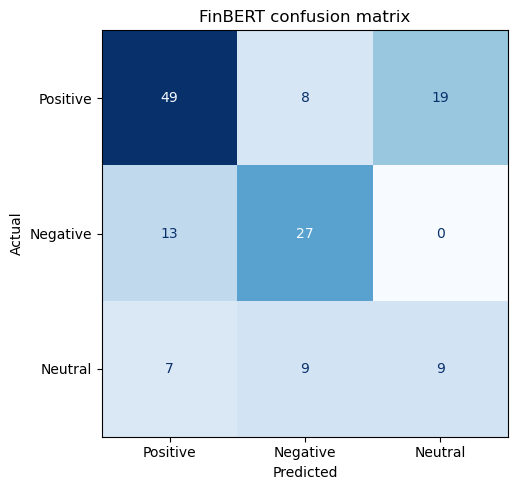

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

labels = ['Positive', 'Negative', 'Neutral']

cm = confusion_matrix(df_comparison['sentiment'], df_comparison['finbert'], labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('FinBERT confusion matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
lexicon = {
    'negative': [
        # inflation and price pressure patterns
        'inflation edges up', 'inflation climbs', 'inflation accelerates',
        'inflation rises', 'prices rise', 'consumer prices rise',
        'cost pressures', 'fuel subsidies removed', 'fuel levy',
        'transport costs remain elevated', 'food and energy price',
        'price pass-through', 'highest level since',
        # shilling weakness
        'on back foot', 'dollar demand from energy importers',
        # lending and credit stress
        'bank lending rates expected to rise', 'non-performing loan ratio rises',
        'amid tight credit', 'policy tightening',
        # crackdown/shutdown
        'operators shut', 'crackdown',
        # rate increases as negative
        'raises benchmark rate', 'surprise move to anchor',
        # import competition stress
        'import competition intensifies', 'tariff relief',
        # capital buffer stress
        'ordered to improve capital buffer', 'stress test',
    ],
    'positive': [
        # debt clearance is good news
        'clears domestic arrears', 'clears pension fund arrears',
        # inflation falling is good
        'inflation falls', 'inflation drops', 'food prices moderate',
        'disinflation', 'meeting bot medium-term target',
        'below central bank target', 'boosting purchasing power',
        # shilling stability
        'shilling steady', 'shilling holds', 'sustains market liquidity',
        'supported by tourism',
        # trade improvements
        'export ban lifted', 'deficit narrows',
        'import duties suspended', 'suspends import duties',
    ],
    'neutral': [
        # policy holds are status updates not good or bad
        'rate hold', 'signals rate hold', 'signals possible rate review',
        'holds rate', 'hold into', 'citing external inflation risks',
        'final meeting', 'keeps rate at', 'holds benchmark rate steady',
        'signals readiness to ease', 'intervenes in forex market',
        # budget and parliamentary approvals
        'approves tzs', 'national budget',
        # launches and announcements with no outcome yet
        'launches regulatory sandbox', 'introduces mobile trading',
        'joins african continental', 'joins pan-african',
        'sign cross-border trade', 'memorandum',
        'api open banking', 'goes live across',
        'rolls out trade finance', 'issues first green bond',
        'crosses five million', 'record tzs',
        'annual review', 'praises tanzania',
        'launches national digital', 'launches diaspora',
        'launches instant cross-border', 'launches sme',
        'opens new regional', 'supply chain finance platform',
        # stability language
        'signalling stability', 'for second consecutive month',
    ]
}

In [29]:
def apply_lexicon(row):
    headline_lower = row['headline'].lower()
    
    # check each category in the lexicon
    for sentiment, phrases in lexicon.items():
        for phrase in phrases:
            if phrase in headline_lower:
                return sentiment.capitalize()
    
    # if no phrase matched, trust finbert
    return row['finbert']

# apply it and store as new column
df_comparison['finbert_enhanced'] = df_comparison.apply(apply_lexicon, axis=1)

# check new accuracy
from sklearn.metrics import accuracy_score
original = accuracy_score(df_comparison['sentiment'], df_comparison['finbert'])
enhanced = accuracy_score(df_comparison['sentiment'], df_comparison['finbert_enhanced'])

print(f"FinBERT original:  {original:.2%}")
print(f"FinBERT enhanced:  {enhanced:.2%}")

FinBERT original:  60.28%
FinBERT enhanced:  80.14%


In [30]:
enhanced_errors = df_comparison[
    df_comparison['finbert_enhanced'] != df_comparison['sentiment']
][['headline', 'sentiment', 'finbert_enhanced', 'finbert_score']]

print(f"Remaining errors: {len(enhanced_errors)}")
print(enhanced_errors.to_string())

Remaining errors: 28
                                                                            headline sentiment finbert_enhanced  finbert_score
4                   Tanzania inflation holds at 3.5% as food prices remain contained   Neutral         Negative       0.650709
11          Tanzania joins African Continental Free Trade Area digital payment pilot  Positive          Neutral       0.880705
13                  Airtel Money Tanzania crosses five million active user milestone  Positive          Neutral       0.781259
15        CRDB Bank launches diaspora remittance product targeting Tanzanians abroad  Positive          Neutral       0.748511
22                              BoT launches regulatory sandbox for fintech startups  Positive          Neutral       0.854661
37             Vodacom Tanzania M-Pesa reports record TZS 2.1 trillion monthly float  Positive          Neutral       0.859162
42                 CRDB Bank issues first green bond on Dar es Salaam Stock Exchange  Posi

In [31]:
print(f"Total enhanced errors: {enhanced_errors["sentiment"].count()}")

Total enhanced errors: 28


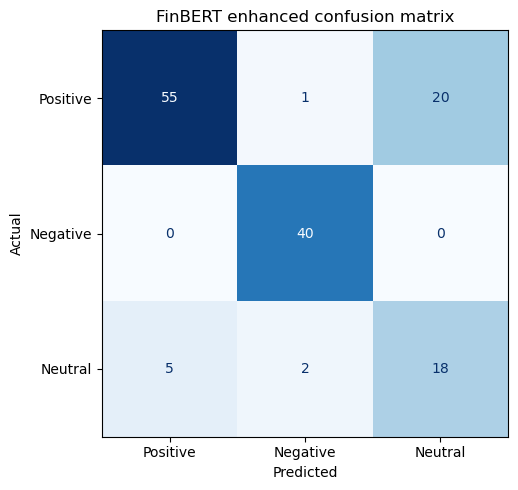

In [34]:
cm_enhanced = confusion_matrix(df_comparison['sentiment'], df_comparison['finbert_enhanced'], labels=labels)
disp_enhanced = ConfusionMatrixDisplay(confusion_matrix=cm_enhanced, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 5))
disp_enhanced.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('FinBERT enhanced confusion matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [73]:
import os
from openai import OpenAI
k2_key = os.getenv("OPENAI_API_KEY")

client = OpenAI(api_key=k2_key)
system_prompt = """You are classifying the ECONOMIC IMPACT of East African financial news headlines.

Positive:
Likely improves growth, stability, investment, consumer conditions, or business activity.

Negative:
announcements, budget approvals, and new guidelines where no outcome is speculated yet, or steady state with no directional signal

Neutral:
Informational updates, announcements, or events without a clear positive or negative economic implication.

Focus on the likely economic effect implied by the headline, not emotional tone.

Return only:
1. Positive
2. Negative
3. Neutral
""" 

# simple gpt call

# def openai_sentiment(headline):
#     response = client.chat.completions.create(
#         model="gpt-4o-mini",
#         messages=[
#             {
#                 "role": "system",
#                 "content": """You are a financial sentiment classifier for East African economic news.

# Classify the sentiment of the headline as exactly one of: Positive, Negative, or Neutral.

# - Positive: growth, improvement, record highs, rate cuts, debt clearance, export growth
# - Negative: decline, crisis, currency weakness, rate hikes under stress, NPLs rising, shutdowns
# - Neutral: policy holds, announcements with no clear outcome, regulatory launches, budget approvals

# Respond with ONLY one word: Positive, Negative, or Neutral."""
#             },
#             {
#                 "role": "user",
#                 "content": headline
#             }
#         ],
#         temperature=0
#     )
#    return response.choices[0].message.content.strip()

In [49]:
df_comparison["openai"] = df_comparison["headline"].apply(openai_sentiment)

print(f"FinBERT accuracy:  {accuracy_score(df_comparison['sentiment'], df_comparison['finbert']):.2%}")
print(f"OpenAI accuracy:   {accuracy_score(df_comparison['sentiment'], df_comparison['openai']):.2%}")

FinBERT accuracy:  60.28%
OpenAI accuracy:   92.20%


In [50]:
openai_errors = df_comparison[
    df_comparison['openai'] != df_comparison['sentiment']
][['headline', 'sentiment', 'openai']]

print(f"Remaining errors: {len(openai_errors)}")
print(openai_errors.to_string())

Remaining errors: 11
                                                                         headline sentiment    openai
22                           BoT launches regulatory sandbox for fintech startups  Positive   Neutral
34   Local manufacturers call for tariff relief as import competition intensifies  Negative   Neutral
53     Unlicensed forex bureaus crackdown sees 15 operators shut in Dar es Salaam   Neutral  Negative
55                         Shilling steadies briefly after rate hike announcement  Positive   Neutral
57            Tanzania government increases fuel levy to fund road infrastructure  Negative   Neutral
65              Tanzania launches national digital payments strategy through 2027  Positive   Neutral
85                    CRDB Bank and NMB Bank announce API open banking initiative  Positive   Neutral
90       Annual CPI inflation ends 2023 at 4.8% below central bank target ceiling  Positive  Negative
97       Stanbic Tanzania ordered to improve capital buffer a

In [74]:
import time

def openai_sentiment_batch(headlines, batch_size=25, system_prompt=system_prompt):
    all_results = []
    batches = [headlines[i:i+batch_size] for i in range(0, len(headlines), batch_size)]
    
    for batch_num, batch in enumerate(batches):
        print(f"Processing batch {batch_num + 1}/{len(batches)} ({len(batch)} headlines)...")
        
        numbered = "\n".join([f"{i+1}. {h}" for i, h in enumerate(batch)])
        
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": numbered}
                ],
                temperature=0
            )
            
            lines = response.choices[0].message.content.strip().split("\n")
            batch_results = [line.split(". ", 1)[1].strip() for line in lines if ". " in line]
            
            if len(batch_results) != len(batch):
                print(f"  Warning: expected {len(batch)} results, got {len(batch_results)}")
            
            all_results.extend(batch_results)
            
        except Exception as e:
            print(f"  Batch {batch_num + 1} failed: {e}")
            all_results.extend(["Error"] * len(batch))
        
        if batch_num < len(batches) - 1:
            time.sleep(1)
    
    return all_results

In [75]:
headlines_list = df_comparison["headline"].tolist()
results = openai_sentiment_batch(headlines_list, 70)
df_comparison["openai"] = results

print(len(results))  # should be len of number of headlines entered
print(df_comparison["openai"].unique())  # should only be Positive, Negative, Neutral

print(f"FinBERT accuracy:  {accuracy_score(df_comparison['sentiment'], df_comparison['finbert']):.2%}")
print(f"OpenAI accuracy:   {accuracy_score(df_comparison['sentiment'], df_comparison['openai']):.2%}")

Processing batch 1/3 (70 headlines)...
Processing batch 2/3 (70 headlines)...
Processing batch 3/3 (1 headlines)...
141
['Neutral' 'Positive' 'Negative']
FinBERT accuracy:  60.28%
OpenAI accuracy:   91.49%


In [72]:
openai_errors = df_comparison[
    df_comparison['openai'] != df_comparison['sentiment']
][['headline', 'sentiment', 'openai']]

print(f"Remaining errors: {len(openai_errors)}")
print(openai_errors.to_string())

Remaining errors: 14
                                                                           headline sentiment    openai
17                Bank of Tanzania intervenes in forex market to stabilise shilling   Neutral  Positive
20       Tanzania Parliament approves TZS 41.4 trillion national budget for 2022/23   Neutral  Positive
26        Bank of Tanzania raises minimum capital requirements for commercial banks   Neutral  Negative
46                Tanzania sets ambitious revenue targets in mid-year budget review   Neutral  Positive
53       Unlicensed forex bureaus crackdown sees 15 operators shut in Dar es Salaam   Neutral  Negative
55                           Shilling steadies briefly after rate hike announcement  Positive   Neutral
64              BoT introduces new foreign exchange management guidelines for banks   Neutral  Positive
70   Inflation peaks at 5.5% in June data released by National Bureau of Statistics  Negative   Neutral
76            Digital lending regulations t